In [29]:
import warnings
from pathlib import Path

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from FeDa4Fair.dataset.fair_dataset import FairFederatedDataset
from FeDa4Fair.metrics.fairness import _compute_fairness, compute_fairness
from FeDa4Fair.utils.data_utils import generate_modification_dict

warnings.filterwarnings("ignore")

## 1. Example of FairFederatedDataset without bias injection using Dutch Dataset

In this case we just want to create a federated dataset from the Dutch Census dataset without injecting any bias. We split the training set into 10 partitions to simulate 10 clients. The label column is occupation_binary while the sensitive attribute is sex_binary.
Here we use Demographic Parity as fairness metric.

In [30]:
# Path to store the dataset partitions
output_path = "./dutch_data"

In [31]:
# Initialize FairFederatedDataset with the generic HF dataset "lucacorbucci/Dutch_Census"
fds = FairFederatedDataset(
    dataset="lucacorbucci/Dutch_Census",
    partitioners={"train": 10},
    label_name="occupation_binary",
    sensitive_attributes=["sex_binary"],
    fairness_metric="DP",
    path=Path(output_path),
)

Dataset initialized. Preparing and saving to ./dutch_data...
Dataset prepared and saved.


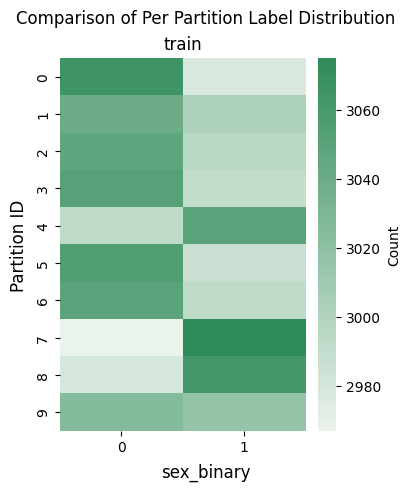

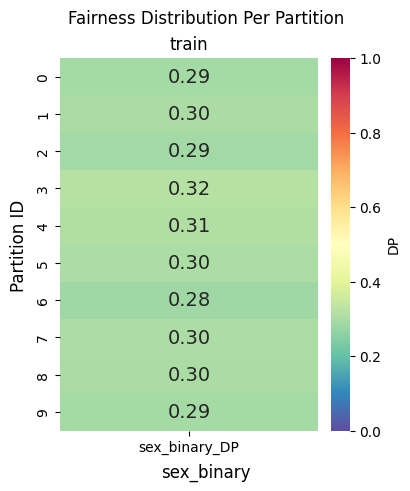

In [32]:
print(f"Dataset initialized. Preparing and saving to {output_path}...")
fds.prepare()
print("Dataset prepared and saved.")

In [33]:
# Access a partition
client_0 = fds.load_partition(0, split="train")
print(f"Client 0 (train) size: {len(client_0)}")

Client 0 (train) size: 6042


In [34]:
# Evaluate and PRINT fairness metrics (Demographic Parity)
print("\nComputing Fairness Metrics on Partitions (Data Bias):")

# We use compute_fairness directly to get the results as a DataFrame for printing
partitioner = fds.partitioners["train"]

metrics_df = compute_fairness(
    partitioner=partitioner,
    partitioner_test=partitioner,  # Using same for data bias check
    model=None,
    sens_att="sex_binary",
    fairness_metric="DP",
    label_name=fds.label_column,
    size_unit="attribute",
)

print("\nFairness Results (Demographic Parity Difference):")
print(metrics_df)

print("\nExample finished successfully.")


Computing Fairness Metrics on Partitions (Data Bias):

Fairness Results (Demographic Parity Difference):
              sex_binary_DP  sex_binary_val
Partition ID                               
0                  0.292508        0.292508
1                  0.299021        0.299021
2                  0.287795        0.287795
3                  0.316753        0.316753
4                  0.311590        0.311590
5                  0.302590        0.302590
6                  0.281884        0.281884
7                  0.302469        0.302469
8                  0.299806        0.299806
9                  0.290243        0.290243

Example finished successfully.


In [35]:
# Evaluate and PRINT fairness metrics (Demographic Parity)
print("\nComputing Fairness Metrics on Partitions (Data Bias):")

# We use compute_fairness directly to get the results as a DataFrame for printing
partitioner = fds.partitioners["train"]

metrics_df = compute_fairness(
    partitioner=partitioner,
    partitioner_test=partitioner,  # Using same for data bias check
    model=None,
    sens_att="sex_binary",
    fairness_metric="DP",
    label_name=fds.label_column,
    size_unit="attribute",
)

print("\nFairness Results (Demographic Parity Difference):")
print(metrics_df)

print("\nExample finished successfully.")


Computing Fairness Metrics on Partitions (Data Bias):

Fairness Results (Demographic Parity Difference):
              sex_binary_DP  sex_binary_val
Partition ID                               
0                  0.292508        0.292508
1                  0.299021        0.299021
2                  0.287795        0.287795
3                  0.316753        0.316753
4                  0.311590        0.311590
5                  0.302590        0.302590
6                  0.281884        0.281884
7                  0.302469        0.302469
8                  0.299806        0.299806
9                  0.290243        0.290243

Example finished successfully.


## 2. Example with bias injection and Dutch Census dataset

Now we inject some biases into the dataset. We use the same setup as before.

In [36]:
# Define modification dict using the helper function
# Here we use named clients and specify both drop and flip rate ranges
client_names = [f"Region_{i}" for i in range(10)]

mod_dict = generate_modification_dict(
    client_ids=client_names,
    attribute="sex_binary",
    value=1,
    drop_rate_range=(0.0, 0.1),
    flip_rate_range=(0.0, 0.2),
    secondary_attribute="age",
    secondary_value=6,
)
print(f"Modification dict for {client_names[0]}: {mod_dict[client_names[0]]}")

Modification dict for Region_0: {'sex_binary': {'drop_rate': 0.0, 'flip_rate': 0.0, 'value': 1, 'attribute': 'age', 'attribute_value': 6}}


In [37]:
# Initialize FairFederatedDataset with the generic HF dataset "lucacorbucci/Dutch_Census"
fds = FairFederatedDataset(
    dataset="lucacorbucci/Dutch_Census",
    partitioners={"train": 10},
    label_name="occupation_binary",
    sensitive_attributes=["sex_binary"],
    fairness_metric="DP",
    path=Path(output_path),
    fairness_level="attribute",
    modification_dict=mod_dict,
    client_names=client_names,
)

## 3. Train local models on the Dutch Census federated dataset with bias injection

We train a simple Logistic regression model on the first two partitions of the generated datasets. Then, we evaluate the accuracy and the unfairness of the local models.

Accuracy on 0: 0.8023159636062862
Unfairness for 0, partition 0, sensitive attribute sex_binary: 0.3414155406145288
--------------------------------------------------
Accuracy on 1: 0.8213399503722084
Unfairness for 1, partition 0, sensitive attribute sex_binary: 0.3584646455800818
--------------------------------------------------
Accuracy on 2: 0.826302729528536
Unfairness for 2, partition 0, sensitive attribute sex_binary: 0.32031930811095216
--------------------------------------------------
Accuracy on 3: 0.8296112489660876
Unfairness for 3, partition 0, sensitive attribute sex_binary: 0.3415658694105413
--------------------------------------------------
Accuracy on 4: 0.8271298593879239
Unfairness for 4, partition 0, sensitive attribute sex_binary: 0.3783261426600381
--------------------------------------------------
Accuracy on 5: 0.8304383788254756
Unfairness for 5, partition 0, sensitive attribute sex_binary: 0.37873096474536494
------------------------------------------------

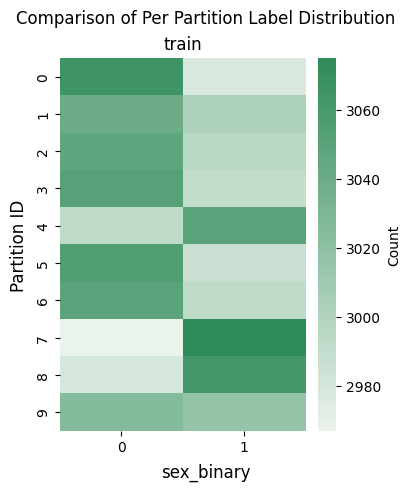

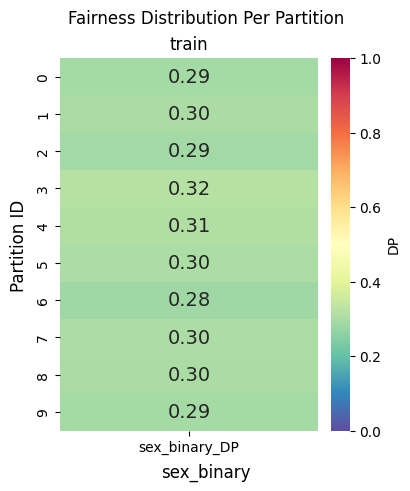

In [38]:
clients = list(range(10))
for client in clients:
    dataset = fds.load_partition(partition_id=client)
    train, test = train_test_split(dataset.to_pandas(), test_size=0.2, random_state=42)
    # train a simple logistic regression model
    model = LogisticRegression()
    model.fit(train.drop(columns=["occupation_binary"]), train["occupation_binary"])
    # evaluate the model on the test set
    accuracy = model.score(test.drop(columns=["occupation_binary"]), test["occupation_binary"])
    print(f"Accuracy on {client}: {accuracy}")

    y_test = test["occupation_binary"]
    preds = model.predict(test.drop(columns=["occupation_binary"]))
    fairness_metric = "DP"
    fairness_level = "attribute"
    sens_att = "sex_binary"
    sf_data = pd.DataFrame(
        {
            "sex_binary": [int(item) for item in test["sex_binary"]],
        }
    )
    unfairness = _compute_fairness(
        y_true=y_test,
        y_pred=preds,
        sf_data=sf_data,
        fairness_metric=fairness_metric,
        sens_att=sens_att,
        size_unit=fairness_level,
    )
    print(f"Unfairness for {client}, sensitive attribute {sens_att}: {unfairness[0]}")
    print("-" * 50)

## 4. Training of a Federated Learning model on the Dutch Census federated dataset with bias injection

## 5. Example with groups and distributions by group

In this section, we demonstrate how to create a more complex federated environment where clients are partitioned into groups (e.g., 'Fair Regions' vs 'Biased Regions'). 

We use the `generate_bias_by_groups` utility, which allows us to specify a mean and standard deviation for bias rates (drop and flip). For each client within a group, the actual bias rate is sampled from a **Truncated Normal Distribution** bounded between 0 and 1. This simulates realistic heterogeneity where clients in the same group behave similarly but not identically.

In [ ]:
from FeDa4Fair.utils.data_utils import generate_bias_by_groups

# 1. Define group configurations
group_configs = [
    {
        "group_id": "Fair_Region",
        "num_clients": 5,
        "sensitive_attr": "sex_binary",
        "sensitive_value": 1,
        "drop_mean": 0.05,
        "drop_std": 0.02,
        "flip_mean": 0.02,
        "flip_std": 0.01,
    },
    {
        "group_id": "Biased_Region",
        "num_clients": 5,
        "sensitive_attr": "sex_binary",
        "sensitive_value": 1,
        "drop_mean": 0.6,
        "drop_std": 0.1,
        "flip_mean": 0.2,
        "flip_std": 0.05,
    },
]

# 2. Generate the modification dictionary
mod_dict_groups = generate_bias_by_groups(num_total_clients=10, group_configs=group_configs)

print(f"Sampled drop rate for a client in Fair_Region: {mod_dict_groups[0]['sex_binary']['drop_rate']:.4f}")
print(f"Sampled drop rate for a client in Biased_Region: {mod_dict_groups[5]['sex_binary']['drop_rate']:.4f}")

# 3. Initialize the dataset with group-based modifications
fds_groups = FairFederatedDataset(
    dataset="lucacorbucci/Dutch_Census",
    partitioners={"train": 10},
    label_name="occupation_binary",
    sensitive_attributes=["sex_binary"],
    fairness_metric="DP",
    path=Path("./dutch_groups_data"),
    modification_dict=mod_dict_groups,
)

fds_groups.prepare()
print("\nGroup-based dataset prepared successfully.")